Listing of All Businesses
https://data.lacity.org/Administration-Finance/Listing-of-All-Businesses/r4uk-afju/about_data


### Dataset explore - different industry distribution

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
df_cleaned = pd.read_csv('dataset\\business_filtered.csv')

In [ ]:
df_naics = pd.read_csv('dataset\\naics_2_clean.csv')
code_sector_dict = df_naics.set_index('Code')['Sector_Title'].to_dict()
df_cleaned['NAICS_2'] = df_cleaned['NAICS'].astype(str).str[:2]
df_cleaned['NAICS_2'] = df_cleaned['NAICS_2'].astype(int)
df_cleaned['NAICS_2_Title'] = df_cleaned['NAICS_2'].map(code_sector_dict)

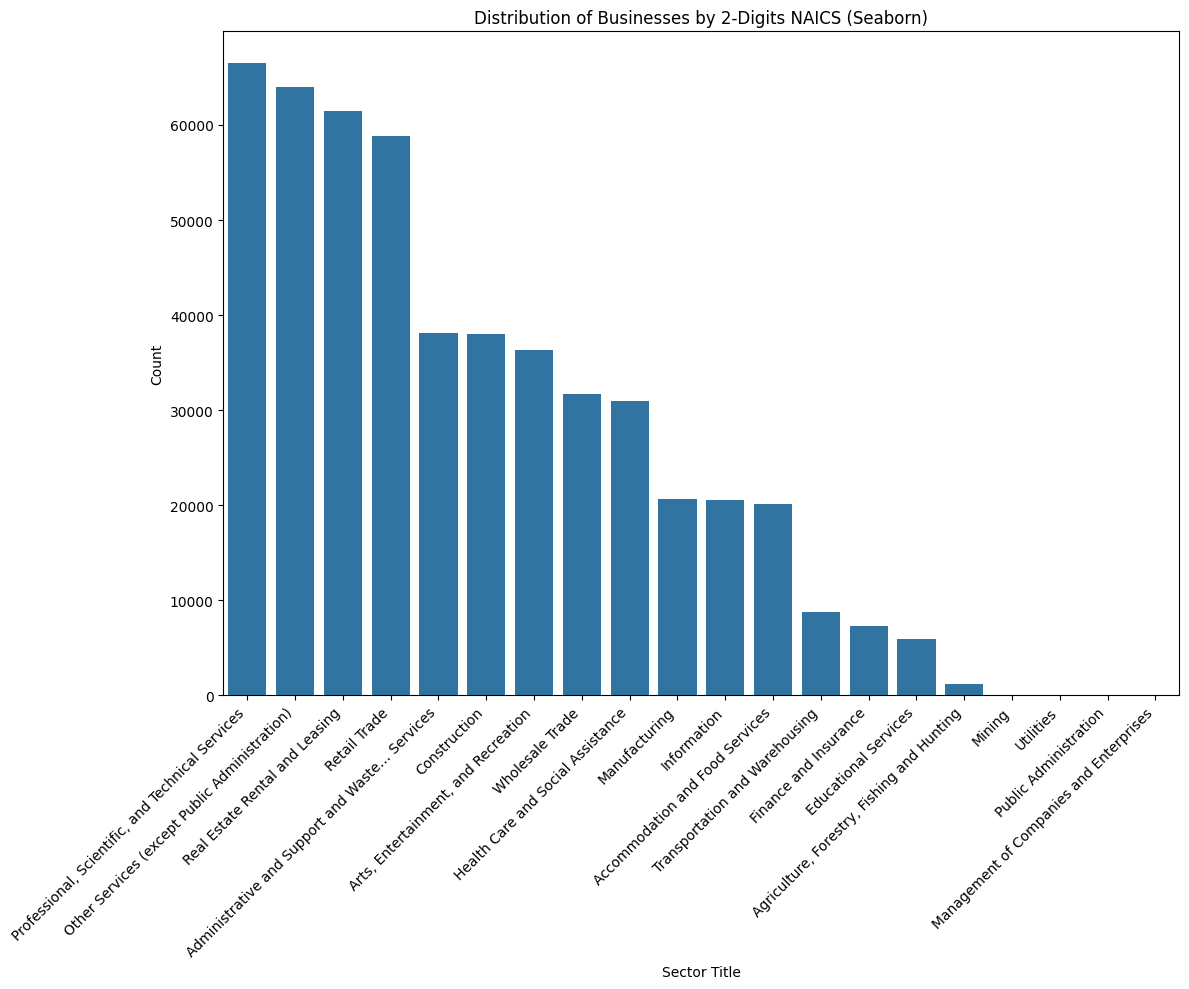

In [ ]:
# df_cleaned

# Count the number of rows (businesses) for each sector title
sector_counts = df_cleaned['NAICS_2_Title'].value_counts().reset_index()
sector_counts.columns = ['NAICS_2_Title', 'count']

# -------------------------------
# Plotting with Seaborn
# -------------------------------
plt.figure(figsize=(12, 10))
sns.barplot(data=sector_counts, x='NAICS_2_Title', y='count')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Sector Title')
plt.ylabel('Count')
plt.title('Distribution of Businesses by 2-Digits NAICS (Seaborn)')
plt.tight_layout()
plt.show()

# -------------------------------
# Plotting with Plotly
# -------------------------------
fig = px.bar(sector_counts, x='NAICS_2_Title', y='count', title='Distribution of Businesses by 2-Digits NAICS (Plotly)')
fig.update_layout(xaxis_tickangle=-45, width=800, height=1000)
fig.show()


##### Select industries for detailed study or compare
Retail & Arts, Entertainment should be two industries if need separate study.

**Reasoning for Retail Trade**

Because retail trade covers a broad spectrum of businesses—from small local stores to big chain stores—covering everything from grocery and apparel to electronics and specialty goods—it often shows clearly in business distribution charts. This industry actively interacts with consumers, creates major employment possibilities, and usually serves as a harbinger for consumer confidence, therefore driving local and national economies. Retail trade success in many areas can be rather closely correlated with more general economic variables such consumer spending patterns and disposable income. Analyzing this industry so offers insightful information on consumer behavior, market trends, and general state of the business environment.

**Reasoning for Arts, Entertainment, and Recreation**

Though typically less in basic commercial terms than certain other industries, arts, entertainment, and recreation are extremely important for forming cultural identity, boosting tourism, and improving local quality of living. This industry encompasses companies like theaters, museums, sports arenas, and other cultural sites that draw both locals and tourists. From job creation to the support of auxiliary businesses like hotel and dining, academics and legislators can better grasp the economic and social impact of creative industries by looking at this area. Its somewhat varied spectrum of activities also makes it an interesting place to investigate in terms of community involvement, customer preferences, and innovation.


In [ ]:
df_retail = df_cleaned[df_cleaned['NAICS_2'].isin([44, 45])]

df_arts = df_cleaned[df_cleaned['NAICS_2'] == 71]

In [ ]:
print(f'retail: {df_retail.shape}\narts: {df_arts.shape}')

retail: (58893, 26)
arts: (36365, 26)


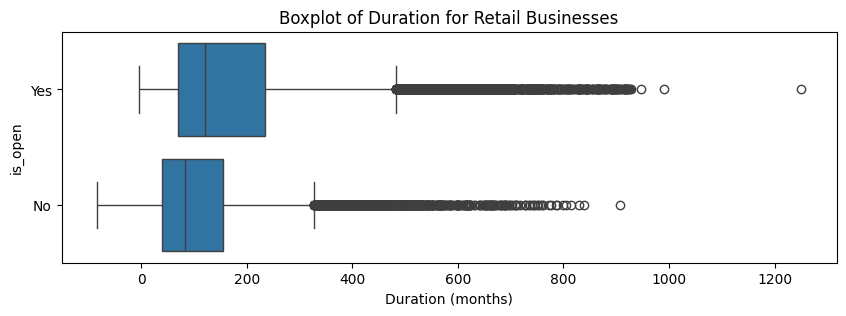

In [ ]:
# Create a boxplot for df_retail 
plt.figure(figsize=(10, 3))
sns.boxplot(data=df_retail, x='duration', y='is_open')
plt.xlabel('Duration (months)')
plt.title('Boxplot of Duration for Retail Businesses')
plt.show()

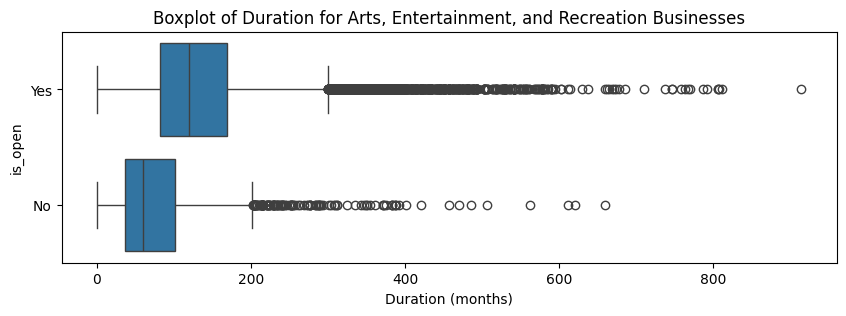

In [ ]:
# Create a boxplot for df_arts
plt.figure(figsize=(10, 3))
sns.boxplot(data=df_arts, x='duration', y='is_open')
plt.xlabel('Duration (months)')
plt.title('Boxplot of Duration for Arts, Entertainment, and Recreation Businesses')
plt.show()

Note: a lot of outliers

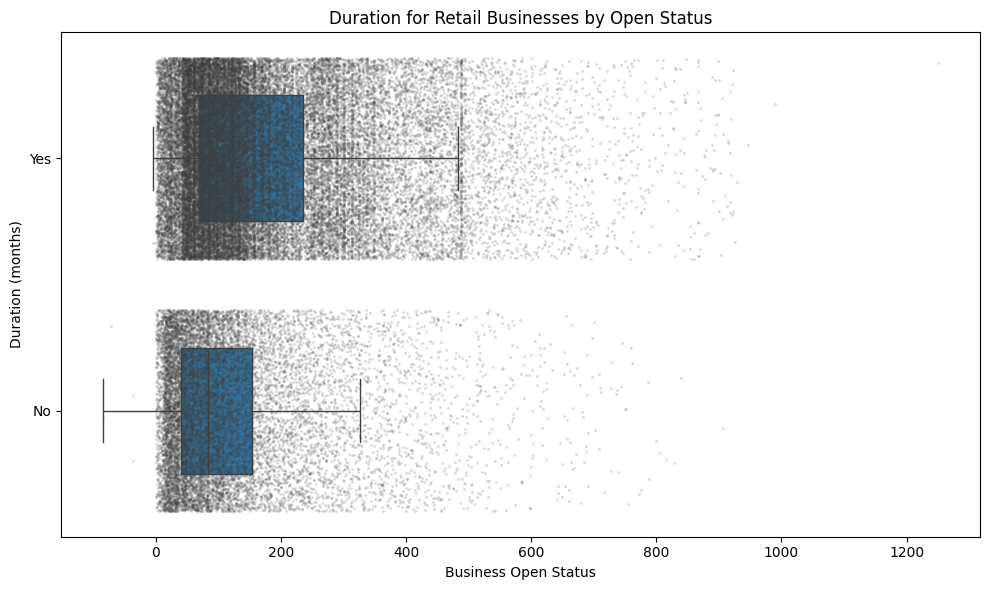

In [ ]:
plt.figure(figsize=(10, 6))

# 1) Swarmplot (or stripplot) for individual points
#    - Swarmplot avoids overlapping points if the dataset isn't too large.
sns.stripplot(
    data=df_retail,
    x='duration',
    y='is_open',
    jitter=0.4,
    alpha=0.2,
    size=2,
    color='0.25'
)

# 2) Boxplot for high-level distribution
sns.boxplot(
    data=df_retail, 
    x='duration',
    y='is_open', 
    showfliers=False,      # optionally hide outliers on the boxplot
    width=0.5
)


plt.xlabel('Business Open Status')
plt.ylabel('Duration (months)')
plt.title('Duration for Retail Businesses by Open Status')
plt.tight_layout()
plt.show()

In [ ]:
print('Retail Businesses(Open):\n', df_retail[df_retail['is_open'] == 'Yes']['duration'].describe(), '\n')
print('Retail Businesses(Closed):\n', df_retail[df_retail['is_open'] == 'No']['duration'].describe(), '\n')

Retail Businesses(Open):
 count    44369.000000
mean       168.254008
std        141.292841
min         -3.914474
25%         69.605263
50%        121.217105
75%        235.164474
max       1250.592105
Name: duration, dtype: float64 

Retail Businesses(Closed):
 count    14524.000000
mean       120.254857
std        117.062670
min        -84.111842
25%         39.671053
50%         83.059211
75%        154.531250
max        907.138158
Name: duration, dtype: float64 



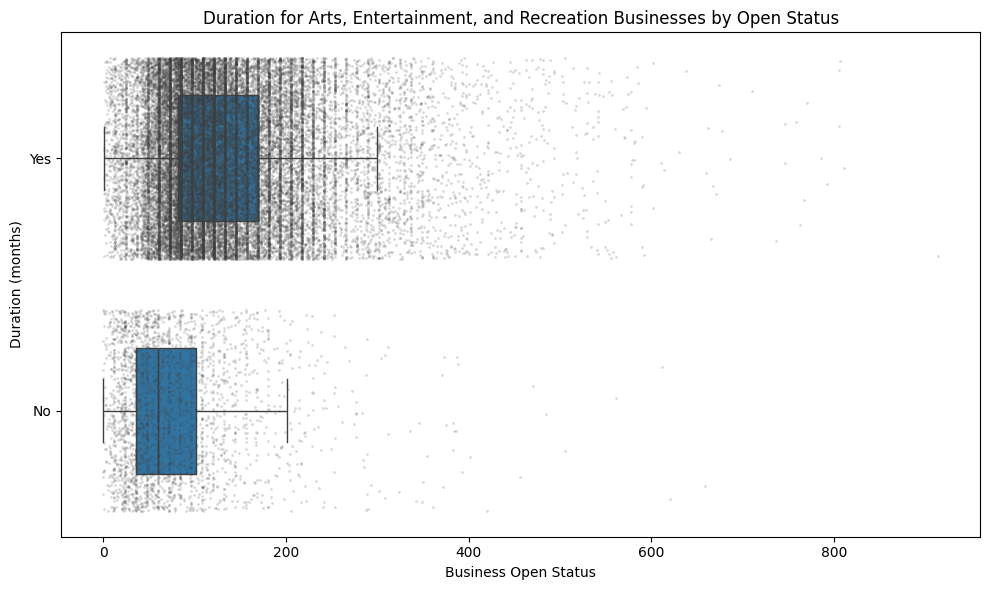

In [ ]:
plt.figure(figsize=(10, 6))

# 1) Swarmplot (or stripplot) for individual points
#    - Swarmplot avoids overlapping points if the dataset isn't too large.
sns.stripplot(
    data=df_arts,
    x='duration',
    y='is_open',
    jitter=0.4,
    alpha=0.2,
    size=2,
    color='0.25'
)

# 2) Boxplot for high-level distribution
sns.boxplot(
    data=df_arts, 
    x='duration',
    y='is_open', 
    showfliers=False,      # optionally hide outliers on the boxplot
    width=0.5
)


plt.xlabel('Business Open Status')
plt.ylabel('Duration (months)')
plt.title('Duration for Arts, Entertainment, and Recreation Businesses by Open Status')
plt.tight_layout()
plt.show()

In [ ]:
print('Arts, Entertainment, and Recreation Businesses(Open):\n', df_arts[df_arts['is_open'] == 'Yes']['duration'].describe(), '\n')
print('Arts, Entertainment, and Recreation Businesses(Closed):\n', df_arts[df_arts['is_open'] == 'No']['duration'].describe(), '\n')

Arts, Entertainment, and Recreation Businesses(Open):
 count    33496.000000
mean       134.321219
std         77.868485
min          0.625000
25%         82.171053
50%        120.131579
75%        169.276316
max        914.177632
Name: duration, dtype: float64 

Arts, Entertainment, and Recreation Businesses(Closed):
 count    2869.000000
mean       77.632565
std        64.550865
min         0.000000
25%        35.986842
50%        60.032895
75%       102.138158
max       658.914474
Name: duration, dtype: float64 



In [ ]:
print(df_arts['start_year'].unique())

[2016 2011 2018 2015 2020 2014 1998 2021 2019 2013 2010 2007 2012 2008
 2017 2009 1999 2005 1987 1997 1990 2024 1970 2006 2004 2023 2022 1993
 1959 1991 1989 2002 2003 1980 1992 2000 2001 1995 1975 1963 1976 1994
 1974 1978 1988 1983 1977 1949 1984 1979 1996 1985 1981 1972 1982 1986
 1958 1957 1961 1962 1966 1969 1968 2025]


### Visualization

In [26]:
import pandas as pd
df_cleaned = pd.read_csv('dataset\\business_filtered.csv')

In [33]:
temp=df_cleaned['start_year'].unique()

In [35]:
import numpy as np
print(np.sort(temp))

[1921 1928 1929 1930 1931 1933 1934 1935 1936 1937 1938 1940 1941 1942
 1943 1944 1945 1946 1947 1948 1949 1950 1951 1952 1953 1954 1955 1956
 1957 1958 1959 1960 1961 1962 1963 1964 1965 1966 1967 1968 1969 1970
 1971 1972 1973 1974 1975 1976 1977 1978 1979 1980 1981 1982 1983 1984
 1985 1986 1987 1988 1989 1990 1991 1992 1993 1994 1995 1996 1997 1998
 1999 2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012
 2013 2014 2015 2016 2017 2018 2019 2020 2021 2022 2023 2024 2025]


In [6]:
df_cleaned.shape

(515273, 24)

In [ ]:
# df_cleaned1['NAICS-2'] = df_cleaned1['NAICS'].map(lambda n: int(n / 10000))
# df_cleaned1.to_csv('dataset\\business_subset.csv', index=False)

In [30]:
import pandas as pd
url = 'https://raw.githubusercontent.com/EricSJSU-DataScience/CS163_project/refs/heads/main/dataset/business_subset.csv'
file_path = 'dataset\\business_subset.csv'
df_map = pd.read_csv(url)

In [32]:
df_map.head(5)

,BUSINESS NAME,STREET ADDRESS,NAICS,latitude,longitude,5d_zip,NAICS-2
0,MARIA OFELIA NUNEZ,1017 W 88TH STREET,444130,33.9581,-118.2926,90044,44
1,SKAB INC,21731 VENTURA BLVD SUITE #300,532290,34.1692,-118.6016,91364,53
2,PRODYNAMICS INC,12099 W WASHINGTON UNIT #408,621340,33.9982,-118.4238,90066,62
3,LIZARRAGA TRANSPORT INC,9663 CARRON DRIVE,488000,33.9803,-118.0841,90660,48
4,MARGARIT KARAPETIAN,16425 BUCHET DRIVE,541219,34.2879,-118.4900,91344,54


In [25]:
naics_counts = df_map['NAICS-2'].value_counts().to_dict()
naics_options = [{"label": f"{code} - {code_sector_dict.get(code, 'Unknown')} ({naics_counts.get(code, 0)})", "value": code}
                  for code in sorted(naics_counts.keys())]
naics_options

[{'label': '11 - Agriculture, Forestry, Fishing and Hunting (1184)',
  'value': 11},
 {'label': '21 - Mining (95)', 'value': 21},
 {'label': '22 - Utilities (6)', 'value': 22},
 {'label': '23 - Construction (38060)', 'value': 23},
 {'label': '31 - Manufacturing (12233)', 'value': 31},
 {'label': '32 - Manufacturing (2155)', 'value': 32},
 {'label': '33 - Manufacturing (6310)', 'value': 33},
 {'label': '42 - Wholesale Trade (31694)', 'value': 42},
 {'label': '44 - Retail Trade (30190)', 'value': 44},
 {'label': '45 - Retail Trade (28703)', 'value': 45},
 {'label': '48 - Transportation and Warehousing (5015)', 'value': 48},
 {'label': '49 - Transportation and Warehousing (3745)', 'value': 49},
 {'label': '51 - Information (20579)', 'value': 51},
 {'label': '52 - Finance and Insurance (7347)', 'value': 52},
 {'label': '53 - Real Estate Rental and Leasing (61513)', 'value': 53},
 {'label': '54 - Professional, Scientific, and Technical Services (66525)',
  'value': 54},
 {'label': '55 - Man

In [23]:
df_naics = pd.read_csv('dataset\\naics_2_clean.csv')
code_sector_dict = df_naics.set_index('Code')['Sector_Title'].to_dict()
code_sector_dict

{11: 'Agriculture, Forestry, Fishing and Hunting',
 21: 'Mining',
 22: 'Utilities',
 23: 'Construction',
 31: 'Manufacturing',
 32: 'Manufacturing',
 33: 'Manufacturing',
 42: 'Wholesale Trade',
 44: 'Retail Trade',
 45: 'Retail Trade',
 48: 'Transportation and Warehousing',
 49: 'Transportation and Warehousing',
 51: 'Information',
 52: 'Finance and Insurance',
 53: 'Real Estate Rental and Leasing',
 54: 'Professional, Scientific, and Technical Services',
 55: 'Management of Companies and Enterprises',
 56: 'Administrative and Support and Waste… Services',
 61: 'Educational Services',
 62: 'Health Care and Social Assistance',
 71: 'Arts, Entertainment, and Recreation',
 72: 'Accommodation and Food Services',
 81: 'Other Services (except Public Administration)',
 92: 'Public Administration'}

In [36]:
df_cleaned['NAICS_2'] = df_cleaned['NAICS'].astype(str).str[:2]
df_cleaned['NAICS_2'] = df_cleaned['NAICS_2'].astype(int)

In [37]:
df_cleaned['NAICS_2_Title'] = df_cleaned['NAICS_2'].map(code_sector_dict)

In [38]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 515273 entries, 0 to 515272
Data columns (total 26 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   LOCATION ACCOUNT #         515273 non-null  object 
 1   BUSINESS NAME              515273 non-null  object 
 2   DBA NAME                   173707 non-null  object 
 3   STREET ADDRESS             515273 non-null  object 
 4   CITY                       515271 non-null  object 
 5   ZIP CODE                   515273 non-null  object 
 6   LOCATION DESCRIPTION       515270 non-null  object 
 7   MAILING ADDRESS            232534 non-null  object 
 8   MAILING CITY               232545 non-null  object 
 9   MAILING ZIP CODE           232478 non-null  object 
 10  NAICS                      515273 non-null  int64  
 11  PRIMARY NAICS DESCRIPTION  515273 non-null  object 
 12  COUNCIL DISTRICT           515273 non-null  int64  
 13  LOCATION START DATE        51

### Survival rate
- [Survival Analysis](https://datatab.net/tutorial/survival-analysis)
- [Kaplan Meier Curve](https://datatab.net/tutorial/kaplan-meier-curve)

Kaplan–Meier Estimation:
The survival probability at each event time is computed as:

$$
S(t) = \prod_{t_i \le t} \left( 1 - \frac{d_i}{n_i} \right)
$$

where $d_i$ is the number of events (closures) at time $t_i$ and $n_i$ is the number at risk just before $t_i$.


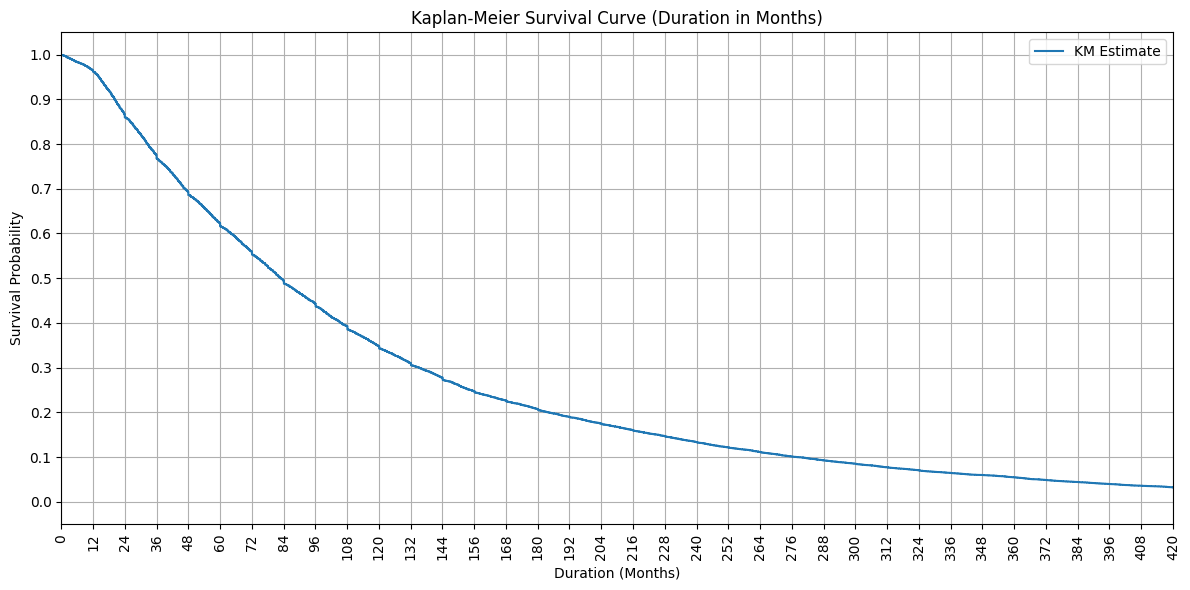

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
# select closed businesses
df_survival = df_retail[df_retail['is_open'] == 'No'].copy()

# round duration
df_survival['duration_rounded'] = df_survival['duration'].round(1)
# count the number of businesses that closed at each duration order by duration.
event_counts = df_survival['duration_rounded'].value_counts().sort_index()

# unique durations 
unique_times = event_counts.index

# Compute the number at risk just before each event time.
# For each unique time t, n_i is the count of businesses with duration >= t.
n_at_risk = [ (df_survival['duration_rounded'] >= t).sum() for t in unique_times ]

# compute the survival probability at each unique time.
# formula: Kaplan-Meier
survival_probs = []
cum_survival = 1.0
for t, d, n in zip(unique_times, event_counts, n_at_risk):
    cum_survival *= (1 - d/n)
    survival_probs.append(cum_survival)

# Determine x-axis tick marks (every 12 months)
max_time = 420 # 600 months = 50 years
xticks = np.arange(0, max_time + 12, 12)
yticks = np.arange(0, 1.1, 0.1)
# Plot the manually computed Kaplan-Meier survival curve.
plt.figure(figsize=(12, 6))
plt.step(unique_times, survival_probs, where='post', label='KM Estimate')
plt.xlabel("Duration (Months)")
plt.ylabel("Survival Probability")
plt.title("Kaplan-Meier Survival Curve (Duration in Months)")
plt.xlim(left=0, right=max_time) # x-axis start from 0
plt.xticks(xticks, rotation=90)
plt.yticks(yticks)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**Note**: only use closed business data isn't correct way to plot kaplan-meier curve, will modify in later app engine component `app_survivalplot.py`. 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_kaplan_meier(df):
    """
    Computes and plots a Kaplan-Meier survival curve for closed businesses.
    Note: Kaplan-Meier is non-parametric method, it does not assume any specific distribution for survival times

    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame containing at least two columns:
         - 'is_open': A column where closed businesses are marked as 'No'.
         - 'duration': The duration (in months) of each business.
    """
    # Select closed businesses
    df_survival = df.copy()

    # Round duration to one decimal place
    df_survival['duration_rounded'] = df_survival['duration'].round(1)
    
    # Count the number of events (business closures) at each unique rounded duration.
    # event_counts = df_survival[df_survival['is_open'] == 'No']['duration_rounded'].value_counts().sort_index()
    event_counts = df_survival[df_survival['is_open'] == False]['duration_rounded'].value_counts().sort_index()
    
    # Unique event times (sorted)
    unique_times = event_counts.index

    # Compute the number at risk just before each event time.
    # For each unique time t, count businesses with duration >= t.
    n_at_risk = [ (df_survival['duration_rounded'] >= t).sum() for t in unique_times ]
    
    # Compute the survival probability at each unique time using the Kaplan-Meier formula.
    survival_probs = []
    cum_survival = 1.0
    for t, d, n in zip(unique_times, event_counts, n_at_risk):
        cum_survival *= (1 - d/n)
        survival_probs.append(cum_survival)
    
    # Set up the x-axis tick marks (every 12 months) and y-axis ticks.
    max_time = 600  # maximum time to display (600 months = 50 years)
    xticks = np.arange(0, max_time + 12, 12)
    yticks = np.arange(0, 1.1, 0.1)
    
    # Plot the Kaplan-Meier survival curve.
    plt.figure(figsize=(10, 8))
    plt.step(unique_times, survival_probs, where='post', label='KM Estimate')
    plt.xlabel("Duration (Months)")
    plt.ylabel("Survival Probability")
    plt.title("Kaplan-Meier Survival Curve (Duration in Months)")
    plt.xlim(left=0, right=max_time)
    plt.xticks(xticks, rotation=90)
    plt.yticks(yticks)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()



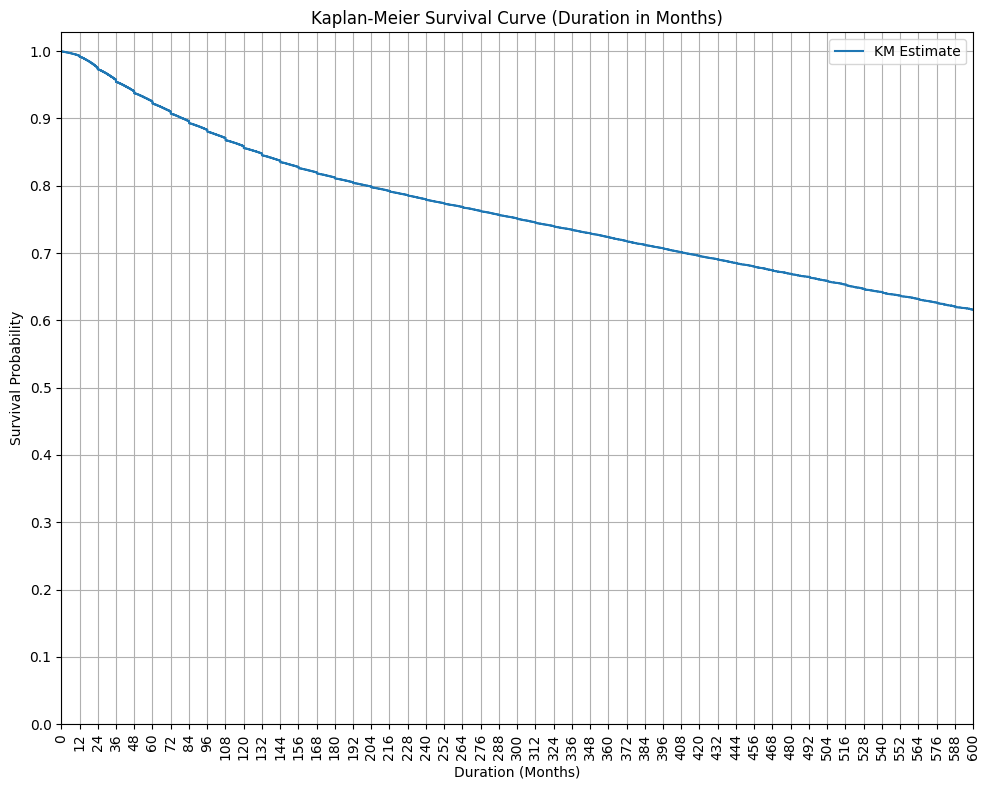

In [ ]:
plot_kaplan_meier(df_cleaned)

Note: it took long to process, large data should be the problem.

In [ ]:
df_cleaned['NAICS_2_Title'].unique()

array(['Retail Trade', 'Real Estate Rental and Leasing',
       'Health Care and Social Assistance',
       'Transportation and Warehousing',
       'Professional, Scientific, and Technical Services',
       'Administrative and Support and Waste… Services',
       'Arts, Entertainment, and Recreation', 'Information',
       'Construction', 'Other Services (except Public Administration)',
       'Wholesale Trade', 'Accommodation and Food Services',
       'Manufacturing', nan, 'Finance and Insurance',
       'Educational Services',
       'Agriculture, Forestry, Fishing and Hunting', 'Mining',
       'Utilities', 'Public Administration',
       'Management of Companies and Enterprises'], dtype=object)

In [ ]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import time

def plot_kaplan_meier_by_industries(df, industries, max_time=600, is_open=False):
    """
    Computes and returns a Plotly figure with Kaplan-Meier survival curves for closed businesses
    for multiple industries.

    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame that must include:
         - 'is_open': dataset modify to boolean dtype recently
         - 'duration': the duration (in months) of each business.
         - 'NAICS-2_Title': the industry classification.
    industries : list
        List of industry names to filter on.
    max_time : int, optional
        Maximum time (in months) to display on the x-axis (default is 600).
    is_open : boolean, optional
        select open/closed business

    Returns:
    --------
    fig : plotly.graph_objects.Figure
        Figure containing Kaplan-Meier survival curves.
    """
    time_start = time.time()
    fig = go.Figure()

    # Loop over each industry in the provided list.
    for industry in industries:
        # Filter for closed businesses in the given industry.
        # original idea may wrong, survival analysis should keep both.
        if pd.isna(industry):
            # df_ind = df[(df["NAICS-2_Title"].isna()) & (df["is_open"] == is_open)].copy()
            df_ind = df[(df["NAICS_2_Title"].isna())].copy()
            industry_label = "NaN"
        else:
            # df_ind = df[(df["NAICS-2_Title"] == industry) & (df["is_open"] == is_open)].copy()
            df_ind = df[(df["NAICS_2_Title"] == industry)].copy()
            industry_label = industry

        # Skip if no data is available for this industry.
        if df_ind.empty:
            continue

        # Round the duration values.
        df_ind["duration_rounded"] = df_ind["duration"].round(1)

        # Count the number of closures (events) at each unique rounded duration.
        # event_counts = df_ind["duration_rounded"].value_counts().sort_index()
        event_counts = df_ind[df_ind["is_open"] == False]["duration_rounded"].value_counts().sort_index()
        unique_times = event_counts.index

        # Compute the number at risk just before each event time.
        n_at_risk = [(df_ind["duration_rounded"] >= t).sum() for t in unique_times]

        # Compute the Kaplan-Meier survival probabilities.
        survival_probs = []
        cum_survival = 1.0
        for t, d, n in zip(unique_times, event_counts, n_at_risk):
            cum_survival *= 1 - d / n
            survival_probs.append(cum_survival)

        # Add a step-like trace for the current industry.
        fig.add_trace(
            go.Scatter(
                x=list(unique_times),
                y=survival_probs,
                mode="lines",
                line_shape="hv",  # horizontal-vertical step plot
                name=str(industry_label),
                text=[
                    f"Industry: {industry_label}<br>Duration: {t} months<br>Survival: {prob:.2f}"
                    for t, prob in zip(unique_times, survival_probs)
                ],
                hoverinfo="text",
            )
        )

    # Define x-axis ticks (every 12 months).
    xticks = list(np.arange(0, max_time + 12, 12))

    # Update the layout.
    fig.update_layout(
        title="Kaplan-Meier Survival Curves by Industry",
        xaxis_title="Duration (Months)",
        yaxis_title="Survival Probability",
        xaxis=dict(
            range=[0, max_time], tickmode="array", tickvals=xticks, tickangle=-90
        ),
        yaxis=dict(range=[0, 1], tickmode="linear", dtick=0.1),
        legend=dict(
            title="Industry", font=dict(size=10), xanchor="right", yanchor="top"
        ),
        width=1000,
        height=600,
    )
    time_end = time.time()
    print(f'survivalplot\tFunction survival curve: {(time_end - time_start): .1f} second')

    return fig

# Example usage:
# industries_list = ['Retail Trade', 'Health Care and Social Assistance', 'Manufacturing']
# plot_kaplan_meier_by_industries(df_retail, industries_list)


In [ ]:
industry_list = [
       'Retail Trade', 
       'Transportation and Warehousing',
       'Professional, Scientific, and Technical Services',
       'Arts, Entertainment, and Recreation', 'Information',
       'Construction', 
       'Wholesale Trade', 'Accommodation and Food Services',
       'Manufacturing', 'Finance and Insurance',
       'Educational Services'
       ]

In [ ]:
plot_kaplan_meier_by_industries(df_cleaned, industry_list, 360)

survivalplot	Function survival curve:  10.8 second


### Try for logrank_test

In [56]:
import pandas as pd
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test, multivariate_logrank_test

# Example data:
# df has columns: 'duration', 'is_open', 'industry'
# is_open == 'No' => event occurred (closed), else censored
# industry => group label
def industry_logrank_test(df, industry_A, industry_B):
    # Suppose you want to compare survival in two industries, A and B:
    df_A = df[(df['NAICS_2_Title'] == industry_A)]
    df_B = df[(df['NAICS_2_Title'] == industry_B)]

    # duration: time to event or censor
    # event_observed: 1 if closed, 0 if still open
    results = logrank_test(
        durations_A = df_A['duration'],
        durations_B = df_B['duration'],
        event_observed_A = (df_A['is_open'] == 'No').astype(int),
        event_observed_B = (df_B['is_open'] == 'No').astype(int)
    )

    return results.print_summary()


In [57]:
industry_A = industry_list[0]
industry_B = industry_list[2]
print(f'{industry_A} vs {industry_B}')
industry_logrank_test(df_cleaned, industry_A, industry_B)

Retail Trade vs Professional, Scientific, and Technical Services


<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
 test_statistic      p  -log2(p)
        1884.07 <0.005       inf

Log-rank χ² = 1 884.1 with 1 df (p ≪ 0.005) shows the two sectors have distinct survival curves—Retail businesses close markedly sooner than Professional, Scientific & Technical Services firms.

In [58]:
results = multivariate_logrank_test(df_cleaned['duration'], df_cleaned['NAICS_2_Title'], df_cleaned['is_open'])
results.print_summary()

<lifelines.StatisticalResult: multivariate_logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 20
         test_name = multivariate_logrank_test

---
 test_statistic      p  -log2(p)
       36016.10 <0.005       inf

The multivariate log-rank test (χ² = 36 016.1, df = 20, p ≪ 0.005) shows that survival times differ significantly across NAICS-2 industries. We can reject the null hypothesis of identical survival curves—industry choice clearly affects business lifespan.

Note: logrank_test used to compare survival distributions between different groups. the survival distributions are significantly different. Kaplan-Meier curve could be more intuitive represent difference. (logrank_test seems useless as right now)

- - -

### Interactive survival curve

In [1]:
import pandas as pd
url = 'https://media.githubusercontent.com/media/EricSJSU-DataScience/CS163_project/refs/heads/main/dataset/business_filtered.csv'
file_path = 'dataset\\business_filtered.csv'
df = pd.read_csv(file_path, usecols=["NAICS", "is_open", "duration"])

In [39]:
df['is_open'].unique()

array([ True, False])

In [2]:
df['NAICS-2'] = df['NAICS'].map(lambda n: int(n / 10000))

In [3]:
df_naics = pd.read_csv('https://raw.githubusercontent.com/EricSJSU-DataScience/CS163_project/refs/heads/main/dataset/naics_2_clean.csv')
code_sector_dict = df_naics.set_index('Code')['Sector_Title'].to_dict()

In [4]:
df['NAICS-2_Title'] = df['NAICS-2'].map(code_sector_dict)

In [ ]:
# df.to_csv('dataset\\business_survivalplot.csv', index=False)

In [17]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go

def plot_kaplan_meier_by_industries(df, industries, max_time=600, p_min=0.5):
    """
    Computes and plots Kaplan-Meier survival curves for closed businesses
    for multiple industries using Plotly.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame that must include:
         - 'is_open': Where closed businesses are marked as 'No'.
         - 'duration': The duration (in months) of each business.
         - 'NAICS_2_Title': The industry classification.
    industries : list
        List of industry names to filter on (e.g., values from df['NAICS_2_Title'].unique()).
    max_time : int, optional
        Maximum time (in months) to display on the x-axis (default is 600).
    """
    
    fig = go.Figure()
    
    # Loop over each industry in the provided list.
    for industry in industries:
        # Filter for closed businesses in the given industry.
        if pd.isna(industry):
            df_ind = df[(df['NAICS-2_Title'].isna())].copy()
            industry_label = "NaN"
        else:
            df_ind = df[(df['NAICS-2_Title'] == industry)].copy()
            industry_label = industry
        
        # Skip if no data is available for this industry.
        if df_ind.empty:
            continue
        
        # Round the duration values.
        df_ind['duration_rounded'] = df_ind['duration'].round(1)
        
        # Count the number of closures (events) at each unique rounded duration.
        event_counts = df_ind[df_ind["is_open"] == False]["duration_rounded"].value_counts().sort_index()
        unique_times = event_counts.index

        # Compute the number at risk just before each event time.
        n_at_risk = [ (df_ind['duration_rounded'] >= t).sum() for t in unique_times ]
        
        # Compute the Kaplan-Meier survival probabilities.
        survival_probs = []
        cum_survival = 1.0
        for t, d, n in zip(unique_times, event_counts, n_at_risk):
            cum_survival *= (1 - d/n)
            survival_probs.append(cum_survival)
        
        # Add a step-like trace for the current industry.
        fig.add_trace(go.Scatter(
            x=list(unique_times),
            y=survival_probs,
            mode='lines',
            line_shape='hv',  # horizontal-vertical step plot
            name=str(industry_label)
        ))
    
    # Define x-axis ticks (every 12 months).
    xticks = list(np.arange(0, max_time + 12, 12))
    yticks = list(np.arange(0.5, 1.1, 0.1))
    
    # Update the layout.
    fig.update_layout(
        title="Kaplan-Meier Survival Curves by Industry",
        xaxis_title="Duration (Months)",
        yaxis_title="Survival Probability",
        xaxis=dict(range=[0, max_time], tickmode='array', tickvals=xticks, tickangle=-90),
        yaxis=dict(range=[p_min, 1], tickmode='linear', dtick=0.1),
        legend=dict(title='Industry', font=dict(size=10), xanchor='right', yanchor='top'),
        width=1000, 
        height=600
    )
    
    fig.show()

# Example usage:
# industries_list = ['Retail Trade', 'Health Care and Social Assistance', 'Manufacturing']
# plot_kaplan_meier_by_industries(df_retail, industries_list)


In [23]:
industry_list = [
       'Retail Trade', 
       'Professional, Scientific, and Technical Services',
       'Arts, Entertainment, and Recreation',
       'Real Estate Rental and Leasing', 
       'Wholesale Trade', 'Accommodation and Food Services',
       'Manufacturing'
       ]

In [9]:
industry_options = [
    {"label": industry, "value": industry} for industry in industry_list
]

In [10]:
industry_options = [
    {"label": industry, "value": industry} 
    for industry in df['NAICS-2_Title'].unique() if pd.notnull(industry)
]

In [61]:
available_industries = sorted(df['NAICS-2_Title'].dropna().unique())

In [25]:
plot_kaplan_meier_by_industries(df, industry_list, 240, 0.6)

**Note**: survival probabiliy noticable drop at yearly interval.

### dataset modify (for `app_survivalplot.py`)

In [26]:
url = 'https://media.githubusercontent.com/media/EricSJSU-DataScience/CS163_project/refs/heads/main/dataset/business_filtered.csv'
file_path = 'dataset\\business_filtered.csv'
df = pd.read_csv(file_path)

In [28]:
df['is_open'] = df['is_open'].map({'Yes': True, 'No': False})

In [ ]:
df.to_csv('dataset\\business_filtered.csv', index=False)

### dataset filter date range

In [25]:
# url = "https://media.githubusercontent.com/media/EricSJSU-DataScience/CS163_project/refs/heads/main/dataset/business_filtered.csv"
data_path = "dataset\\business_filtered.csv"
df = pd.read_csv(data_path)

In [26]:
df = df[df['start_year'] >= 2000]


In [27]:
df = df[['NAICS', 'is_open', 'duration']]

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 444123 entries, 0 to 515272
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   NAICS     444123 non-null  int64  
 1   is_open   444123 non-null  bool   
 2   duration  444123 non-null  float64
dtypes: bool(1), float64(1), int64(1)
memory usage: 10.6 MB


In [29]:
df.to_csv('dataset\\business_filtered_2000after.csv', index=False)